In [4]:
from models.clustering import DeepEmbeddingClustering
from models.decomposition import Autoencoder
from models.user import UserFeaturePreprocessor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

pd.options.display.max_columns = None

In [8]:
videos  = pd.read_csv("./data/KuaiRand-1K/data/video_features_statistic_1k.csv")
X = videos.drop('video_id', axis=1)


In [ ]:
device = "cuda"

encoder = Pipeline([
    ('scaler', MinMaxScaler()),
    ('encoder', Autoencoder(
        encoder=[
            nn.Linear(51, 24), nn.ReLU(), 
            nn.Linear(24, 12), nn.ReLU(), 
            nn.Linear(12, 2)], 
        decoder=[
            nn.Linear(2, 12), nn.ReLU(), 
            nn.Linear(12, 24), nn.ReLU(), 
            nn.Linear(24, 51)], 
        lr=1e-3, 
        batch_size=1000, 
        epochs=100, 
        min_delta=1e-9, 
        device=device
    ))
])

encoder.fit(X)



Training:  28%|██▊       | 124288/437200 [11:36<27:43, 188.09it/s, epoch=29, loss=0.0000] 

In [ ]:
X_encoded = encoder.transform(X.sample(100000, random_state=42))
pd.DataFrame(X_encoded).plot.scatter(x=0, y=1)

In [ ]:
clustering = Pipeline([
    ('standardize', StandardScaler()),
    ('cluster', DeepEmbeddingClustering( n_clusters=25, epochs=100, device=device ))
])
clustering.fit(X_encoded)

<Axes: xlabel='0', ylabel='1'>

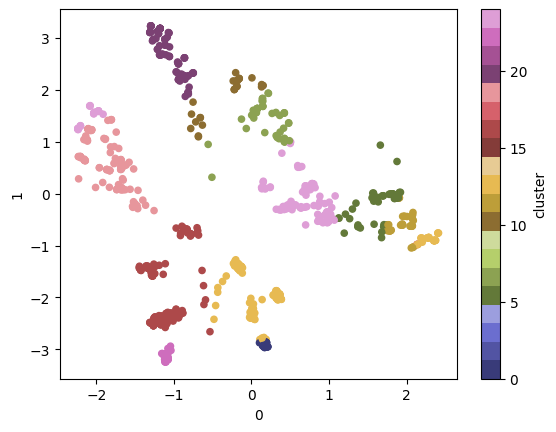

In [ ]:
components = encoder.transform(X)
components = pd.DataFrame(components, columns=['c1', 'c2'])
components['cluster'] = clustering.predict(components)
components['video_id'] = videos['video_id']

pd.DataFrame(components).plot.scatter(x=0, y=1, c='cluster', cmap='tab20b')

In [ ]:
components.to_csv('./data/KuaiRand-1K/data/video_clusters.csv', index=False)